In [12]:
from matplotlib import pyplot as plt
from sklearn.datasets import make_moons

In [13]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = (X - X.mean(axis=0)) / X.std(axis=0)


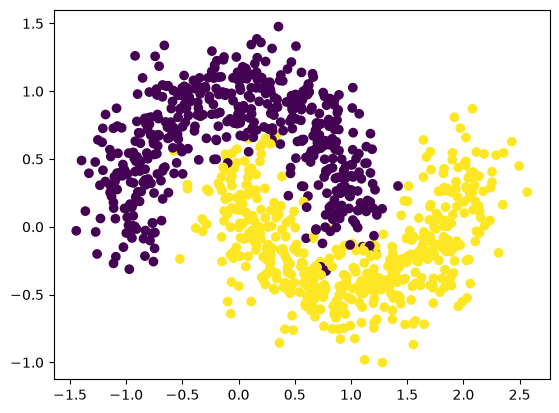

In [14]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [15]:
import numpy as np


In [16]:
HIDDEN_SIZE = 16

class MLP:
    def __init__(self, hidden_size=HIDDEN_SIZE):
        self.W1 = np.random.randn(2, hidden_size) * 0.1
        self.b1 = np.zeros(hidden_size)
        self.W2 = np.random.randn(hidden_size, 1) * 0.1
        self.b2 = np.zeros(1)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def forward(self, x):
        hidden = self.sigmoid(x @ self.W1 + self.b1)
        return self.sigmoid(hidden @ self.W2 + self.b2)


In [17]:
EPOCHS = 3000
LEARNING_RATE = 0.5

mlp = MLP()
losses = []

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    indices = np.random.permutation(len(X))

    for i in indices:
        x_i = X[i]
        y_i = y[i]

        # Forward pass
        z1 = x_i @ mlp.W1 + mlp.b1
        hidden = mlp.sigmoid(z1)
        z2 = hidden @ mlp.W2 + mlp.b2
        prediction = mlp.sigmoid(z2)

        # Loss
        loss = ((prediction - y_i) ** 2).item()
        losses.append(loss)
        epoch_loss += loss

        # Backward pass
        d_loss_d_prediction = 2 * (prediction - y_i)
        d_prediction_d_z2 = prediction * (1 - prediction)
        d_loss_d_z2 = d_loss_d_prediction * d_prediction_d_z2

        d_loss_d_W2 = hidden.reshape(-1, 1) * d_loss_d_z2
        d_loss_d_b2 = d_loss_d_z2
        d_loss_d_hidden = mlp.W2.flatten() * d_loss_d_z2
        d_loss_d_z1 = d_loss_d_hidden * hidden * (1 - hidden)
        d_loss_d_W1 = np.outer(x_i, d_loss_d_z1)
        d_loss_d_b1 = d_loss_d_z1

        # Update weights
        mlp.W1 -= LEARNING_RATE * d_loss_d_W1
        mlp.b1 -= LEARNING_RATE * d_loss_d_b1
        mlp.W2 -= LEARNING_RATE * d_loss_d_W2
        mlp.b2 -= LEARNING_RATE * d_loss_d_b2

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, avg loss: {epoch_loss / len(X):.4f}")


Epoch 0, avg loss: 0.1062
Epoch 100, avg loss: 0.0924
Epoch 200, avg loss: 0.0924
Epoch 300, avg loss: 0.0924
Epoch 400, avg loss: 0.0924
Epoch 500, avg loss: 0.0924
Epoch 600, avg loss: 0.0924
Epoch 700, avg loss: 0.0924
Epoch 800, avg loss: 0.0924
Epoch 900, avg loss: 0.0924


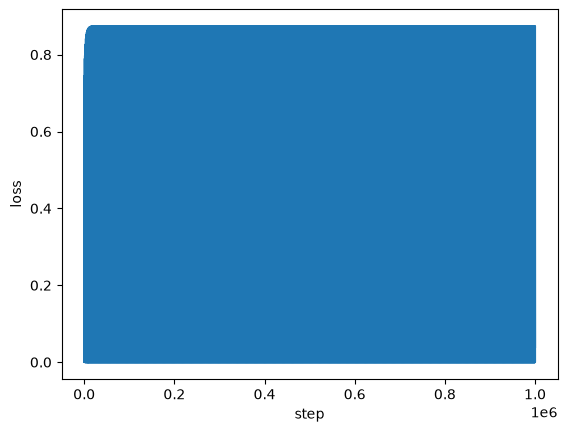

In [18]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Training loss")

plt.subplot(1, 2, 2)
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200),
)
grid = np.c_[xx.ravel(), yy.ravel()]
probs = np.array([mlp.forward(point).item() for point in grid]).reshape(xx.shape)

plt.contourf(xx, yy, probs, levels=50, cmap="RdBu", alpha=0.7)
plt.colorbar(label="predicted probability")
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", s=20)
plt.title("Decision boundary on make_moons")
plt.xlabel("x1")
plt.ylabel("x2")

plt.tight_layout()
plt.show()

predictions = np.array([1 if mlp.forward(x).item() >= 0.5 else 0 for x in X])
accuracy = (predictions == y).mean()
print(f"Training accuracy: {accuracy:.2%}")
